## Imports and paths


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from windrose import WindroseAxes

# ── Paths ──────────────────────────────────────────────────────
MERGED_DIR  = Path("../data/merged")
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

WAVE_FILE = MERGED_DIR / "era5_waves_2014_2024.nc"

# ── Load wave data ─────────────────────────────────────────────
ds_wave = xr.open_dataset(WAVE_FILE)

# Spatial mean over ocean points only
hs  = ds_wave["swh"].mean(dim=["latitude", "longitude"], skipna=True)
mwd = ds_wave["mwd"].mean(dim=["latitude", "longitude"], skipna=True)

# Convert to pandas Series
hs_series  = hs.to_series()
mwd_series = mwd.to_series()

# Drop NaNs — windrose cannot handle them
mask = hs_series.notna() & mwd_series.notna()
hs_clean  = hs_series[mask].values
mwd_clean = mwd_series[mask].values

print(f"Valid hourly records : {len(hs_clean):,}")
print(f"Hs  range : {hs_clean.min():.2f} – {hs_clean.max():.2f} m")
print(f"MWD range : {mwd_clean.min():.1f} – {mwd_clean.max():.1f} °")

Valid hourly records : 96,432
Hs  range : 0.19 – 5.74 m
MWD range : 7.8 – 347.5 °


## Annual wave rose


/var/folders/h4/qx7nkz751x9gd4p_2j2nsv540000gn/T/ipykernel_86306/2357022816.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


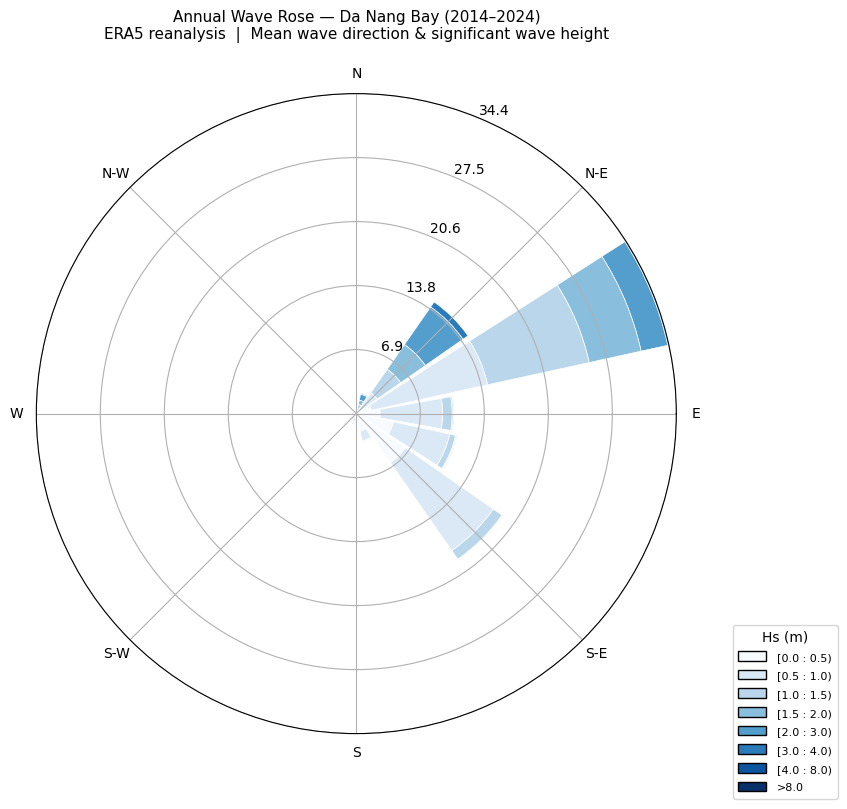

Saved → ../outputs/figures/wave_rose_annual.png


In [2]:
# ── Hs bin edges (m) ───────────────────────────────────────────
# Chosen to reflect operationally meaningful thresholds
bins = [0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 8.0]

# ── Figure ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)

ax.bar(
    mwd_clean,
    hs_clean,
    bins=bins,
    normed=True,          # show frequency (%) not counts
    opening=0.9,
    edgecolor="white",
    lw=0.5,
    nsector=16,           # 16 directional sectors = 22.5° each
    cmap=plt.cm.Blues,
)

ax.set_legend(
    title="Hs (m)",
    loc="lower right",
    bbox_to_anchor=(1.25, -0.1),
    fontsize=10,
)

ax.set_title(
    "Annual Wave Rose — Da Nang Bay (2014–2024)\n"
    "ERA5 reanalysis  |  Mean wave direction & significant wave height",
    fontsize=11,
    pad=20,
)

plt.tight_layout()
out_path = FIGURES_DIR / "wave_rose_annual.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

## Seasonal wave roses


NE monsoon records : 48,120
SW monsoon records : 40,392
NE mean Hs : 1.412 m
SW mean Hs : 0.599 m


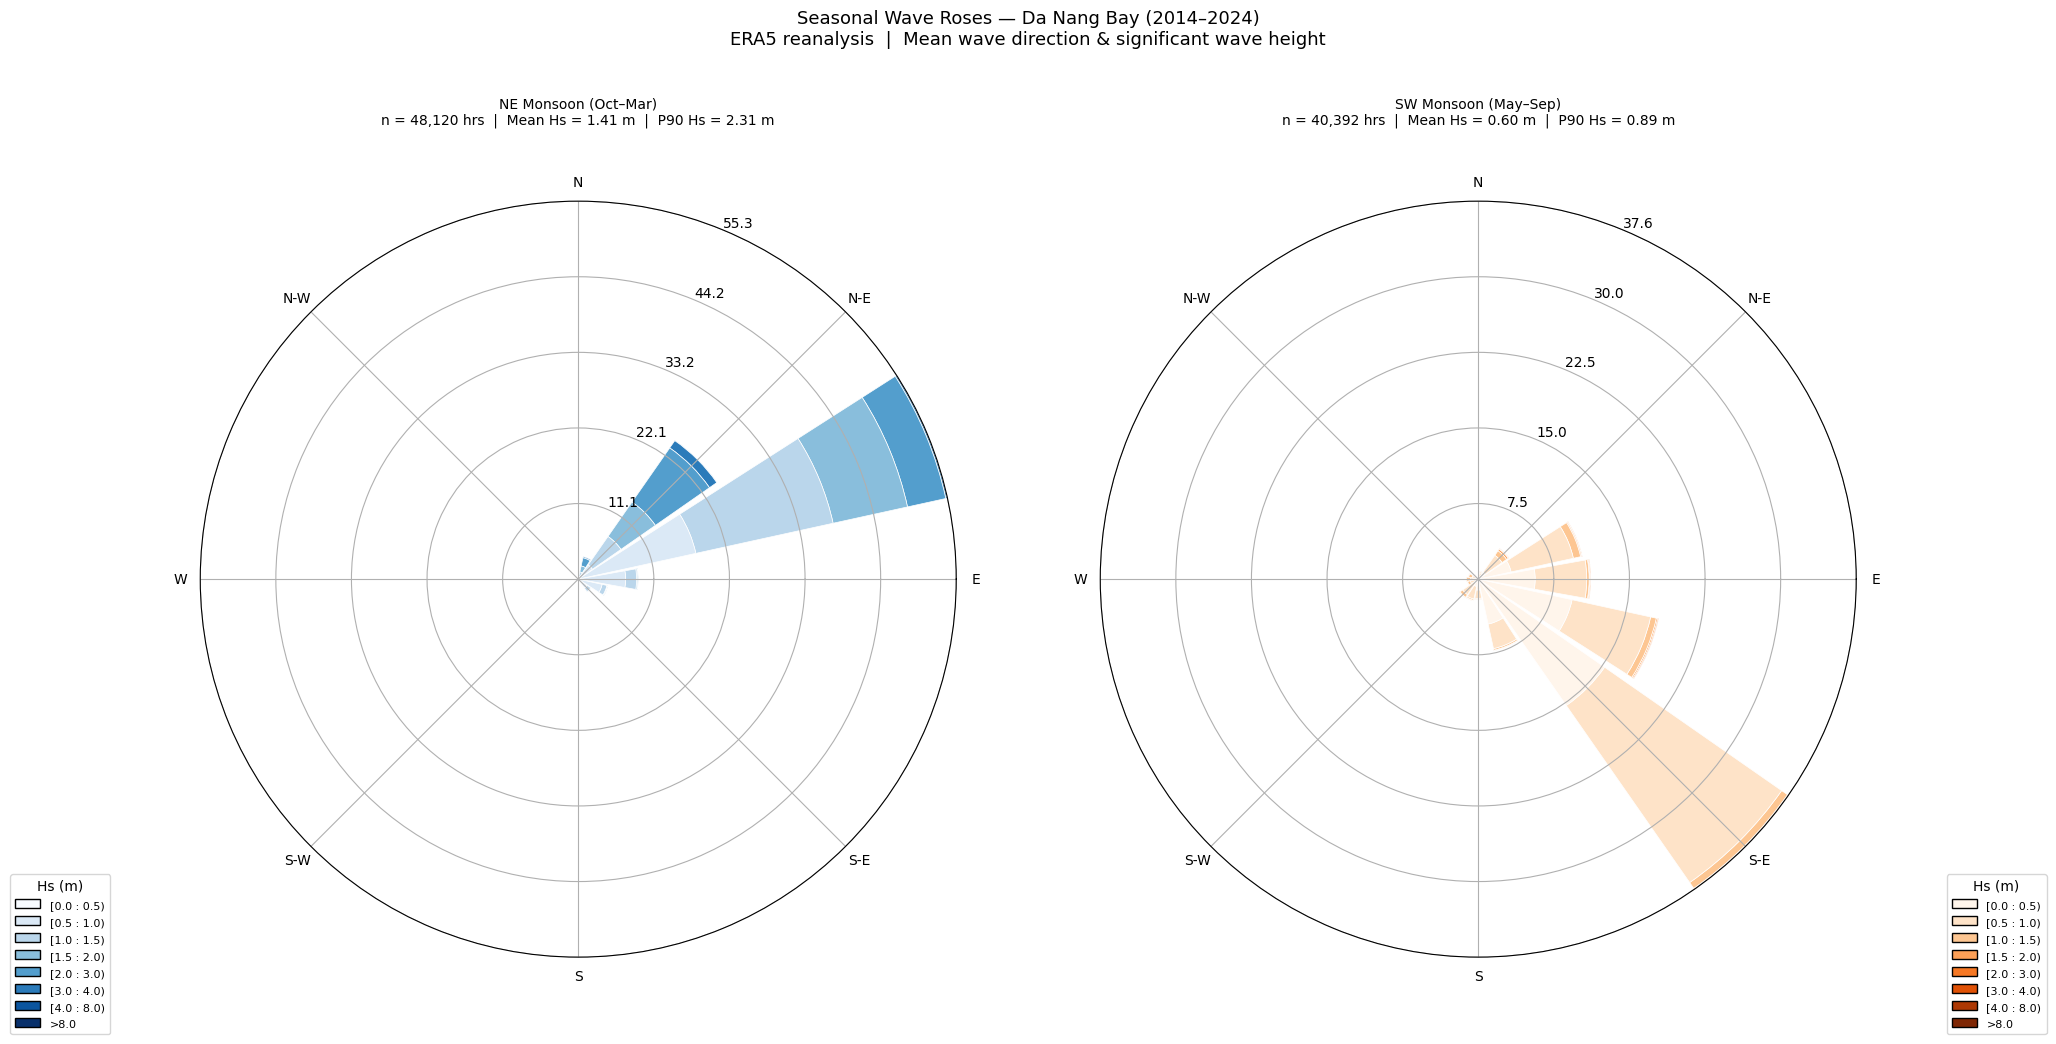

Saved → ../outputs/figures/wave_roses_seasonal.png


In [4]:
# ── Seasonal masks ─────────────────────────────────────────────
NE_MONTHS = [10, 11, 12, 1, 2, 3]
SW_MONTHS = [5, 6, 7, 8, 9]

time_index = hs_series[mask].index

ne_mask = time_index.month.isin(NE_MONTHS)
sw_mask = time_index.month.isin(SW_MONTHS)

hs_ne  = hs_clean[ne_mask]
mwd_ne = mwd_clean[ne_mask]

hs_sw  = hs_clean[sw_mask]
mwd_sw = mwd_clean[sw_mask]

print(f"NE monsoon records : {len(hs_ne):,}")
print(f"SW monsoon records : {len(hs_sw):,}")
print(f"NE mean Hs : {hs_ne.mean():.3f} m")
print(f"SW mean Hs : {hs_sw.mean():.3f} m")

# ── Hs bins ────────────────────────────────────────────────────
bins = [0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 8.0]

# ── Figure ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))

# Shared figure title — given generous top margin so subtitles don't collide
fig.suptitle(
    "Seasonal Wave Roses — Da Nang Bay (2014–2024)\n"
    "ERA5 reanalysis  |  Mean wave direction & significant wave height",
    fontsize=13,
    y=0.98,
)

# ── NE monsoon rose ────────────────────────────────────────────
# Lowered rect to leave room for suptitle and subplot title above
ax_ne = WindroseAxes.from_ax(
    fig=fig,
    rect=[0.04, 0.02, 0.42, 0.78]
)

ax_ne.bar(
    mwd_ne, hs_ne,
    bins=bins,
    normed=True,
    opening=0.9,
    edgecolor="white",
    lw=0.5,
    nsector=16,
    cmap=plt.cm.Blues,
)

ax_ne.set_title(
    "NE Monsoon (Oct–Mar)\n"
    f"n = {len(hs_ne):,} hrs  |  Mean Hs = {hs_ne.mean():.2f} m  "
    f"|  P90 Hs = {np.percentile(hs_ne, 90):.2f} m",
    fontsize=10,
    pad=12,
    y=1.08,       # push subtitle above the rose ring
)

ax_ne.set_legend(
    title="Hs (m)",
    loc="lower left",
    bbox_to_anchor=(-0.25, -0.1),
    fontsize=9,
)

# ── SW monsoon rose ────────────────────────────────────────────
ax_sw = WindroseAxes.from_ax(
    fig=fig,
    rect=[0.54, 0.02, 0.42, 0.78]
)

ax_sw.bar(
    mwd_sw, hs_sw,
    bins=bins,
    normed=True,
    opening=0.9,
    edgecolor="white",
    lw=0.5,
    nsector=16,
    cmap=plt.cm.Oranges,
)

ax_sw.set_title(
    "SW Monsoon (May–Sep)\n"
    f"n = {len(hs_sw):,} hrs  |  Mean Hs = {hs_sw.mean():.2f} m  "
    f"|  P90 Hs = {np.percentile(hs_sw, 90):.2f} m",
    fontsize=10,
    pad=12,
    y=1.08,
)

ax_sw.set_legend(
    title="Hs (m)",
    loc="lower right",
    bbox_to_anchor=(1.25, -0.1),
    fontsize=9,
)

out_path = FIGURES_DIR / "wave_roses_seasonal.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

## Extract annual maxima and fit Gumbel


In [5]:
from scipy import stats

# ── Extract annual maximum Hs ──────────────────────────────────
# One value per year — 2014 to 2024 = 11 values
hs_annual_max = (
    hs_series
    .resample("YE")
    .max()
    .dropna()
)

print("Annual maximum Hs:")
print("─" * 30)
for year, val in hs_annual_max.items():
    print(f"  {year.year} :  {val:.3f} m")
print(f"\n  n = {len(hs_annual_max)} years")
print(f"  Min  : {hs_annual_max.min():.3f} m")
print(f"  Max  : {hs_annual_max.max():.3f} m")
print(f"  Mean : {hs_annual_max.mean():.3f} m")

# ── Fit Gumbel distribution ────────────────────────────────────
# scipy gumbel_r uses MLE by default
loc, scale = stats.gumbel_r.fit(hs_annual_max.values)

print(f"\nGumbel fit parameters:")
print(f"  Location (μ) : {loc:.4f}")
print(f"  Scale    (σ) : {scale:.4f}")

Annual maximum Hs:
──────────────────────────────
  2014 :  3.424 m
  2015 :  3.189 m
  2016 :  3.640 m
  2017 :  3.916 m
  2018 :  3.784 m
  2019 :  3.430 m
  2020 :  5.742 m
  2021 :  4.043 m
  2022 :  4.914 m
  2023 :  3.472 m
  2024 :  4.383 m

  n = 11 years
  Min  : 3.189 m
  Max  : 5.742 m
  Mean : 3.995 m

Gumbel fit parameters:
  Location (μ) : 3.6818
  Scale    (σ) : 0.4851


## Compute return period estimates


In [6]:
# ── Return periods and corresponding Hs ───────────────────────
return_periods = np.array([2, 5, 10, 25, 50, 100])

def gumbel_return_level(T, loc, scale):
    """Return Hs for a given return period T (years)."""
    p = 1 - 1/T          # non-exceedance probability
    return stats.gumbel_r.ppf(p, loc=loc, scale=scale)

hs_return = gumbel_return_level(return_periods, loc, scale)

# ── Bootstrap 90% confidence intervals ────────────────────────
np.random.seed(42)
N_BOOT = 10_000
boot_levels = np.zeros((N_BOOT, len(return_periods)))

for i in range(N_BOOT):
    # Resample annual maxima with replacement
    sample = np.random.choice(hs_annual_max.values,
                               size=len(hs_annual_max),
                               replace=True)
    try:
        b_loc, b_scale = stats.gumbel_r.fit(sample)
        boot_levels[i] = gumbel_return_level(return_periods, b_loc, b_scale)
    except Exception:
        boot_levels[i] = np.nan

ci_lower = np.nanpercentile(boot_levels, 5,  axis=0)
ci_upper = np.nanpercentile(boot_levels, 95, axis=0)

# ── Return period table ────────────────────────────────────────
rp_df = pd.DataFrame({
    "Return Period (yr)"  : return_periods,
    "Hs (m)"              : hs_return.round(2),
    "90% CI Lower (m)"    : ci_lower.round(2),
    "90% CI Upper (m)"    : ci_upper.round(2),
}).set_index("Return Period (yr)")

print("Return Period Table — Gumbel fit:")
print("─" * 45)
print(rp_df.to_string())

# Save to CSV
csv_path = FIGURES_DIR / "return_period_table.csv"
rp_df.to_csv(csv_path)
print(f"\nSaved → {csv_path}")

Return Period Table — Gumbel fit:
─────────────────────────────────────────────
                    Hs (m)  90% CI Lower (m)  90% CI Upper (m)
Return Period (yr)                                            
2                     3.86              3.59              4.21
5                     4.41              3.89              4.98
10                    4.77              4.09              5.50
25                    5.23              4.33              6.17
50                    5.57              4.51              6.67
100                   5.91              4.69              7.17

Saved → ../outputs/figures/return_period_table.csv


## Return period curve


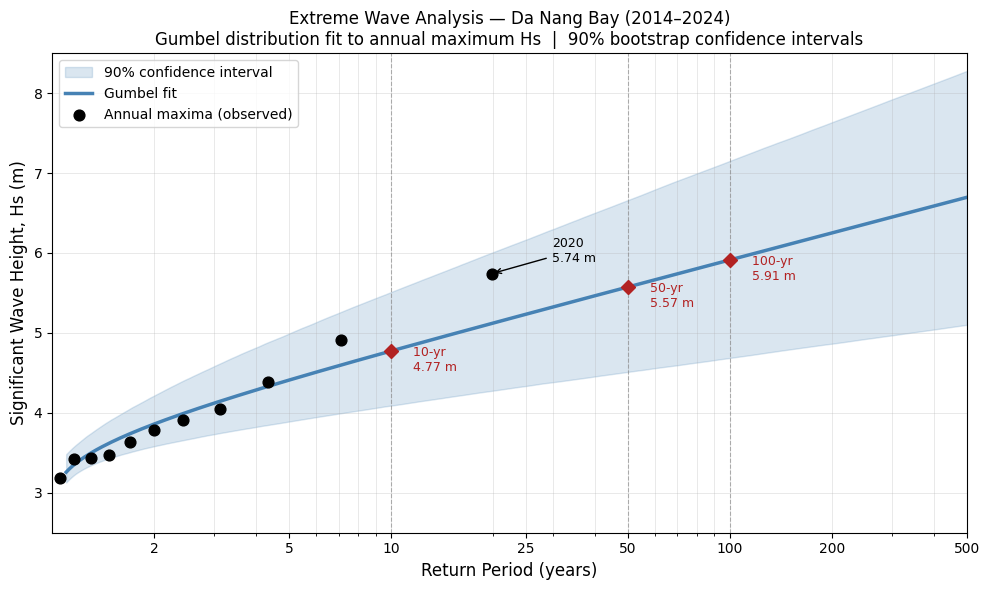

Saved → ../outputs/figures/return_period_curve.png


In [7]:
# ── Smooth Gumbel curve over a wide range of return periods ───
T_smooth   = np.logspace(np.log10(1.1), np.log10(500), 300)
hs_smooth  = gumbel_return_level(T_smooth, loc, scale)
ci_l_smooth = np.zeros(len(T_smooth))
ci_u_smooth = np.zeros(len(T_smooth))

# Bootstrap CI for the smooth curve
boot_smooth = np.zeros((N_BOOT, len(T_smooth)))
for i in range(N_BOOT):
    sample = np.random.choice(hs_annual_max.values,
                               size=len(hs_annual_max),
                               replace=True)
    try:
        b_loc, b_scale = stats.gumbel_r.fit(sample)
        boot_smooth[i] = gumbel_return_level(T_smooth, b_loc, b_scale)
    except Exception:
        boot_smooth[i] = np.nan

ci_l_smooth = np.nanpercentile(boot_smooth, 5,  axis=0)
ci_u_smooth = np.nanpercentile(boot_smooth, 95, axis=0)

# ── Empirical plotting positions (Gringorten formula) ─────────
# Gringorten is recommended for Gumbel — less biased than Weibull
n   = len(hs_annual_max)
hs_sorted = np.sort(hs_annual_max.values)
ranks = np.arange(1, n + 1)
p_emp = (ranks - 0.44) / (n + 0.12)       # Gringorten
T_emp = 1 / (1 - p_emp)                   # empirical return period

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# 90% CI shading
ax.fill_between(T_smooth, ci_l_smooth, ci_u_smooth,
                alpha=0.2, color="steelblue", label="90% confidence interval")

# Fitted Gumbel curve
ax.plot(T_smooth, hs_smooth,
        color="steelblue", lw=2.5, label="Gumbel fit")

# Empirical data points
ax.scatter(T_emp, hs_sorted,
           color="black", zorder=5, s=60, label="Annual maxima (observed)")

# Annotate the 2020 outlier
idx_2020 = np.argmax(hs_sorted)
ax.annotate(
    f"2020\n{hs_sorted[idx_2020]:.2f} m",
    xy=(T_emp[idx_2020], hs_sorted[idx_2020]),
    xytext=(T_emp[idx_2020] * 1.5, hs_sorted[idx_2020] + 0.15),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="black", lw=1),
)

# Mark the key return period estimates
rp_highlights = [10, 50, 100]
for T_val in rp_highlights:
    hs_val = gumbel_return_level(T_val, loc, scale)
    ax.axvline(T_val, color="grey", lw=0.8, ls="--", alpha=0.6)
    ax.plot(T_val, hs_val, marker="D", color="firebrick",
            markersize=7, zorder=6)
    ax.annotate(
        f"  {T_val}-yr\n  {hs_val:.2f} m",
        xy=(T_val, hs_val),
        xytext=(T_val * 1.1, hs_val - 0.25),
        fontsize=9, color="firebrick",
    )

ax.set_xscale("log")
ax.set_xlim(1, 500)
ax.set_ylim(2.5, 8.5)

ax.set_xlabel("Return Period (years)", fontsize=12)
ax.set_ylabel("Significant Wave Height, Hs (m)", fontsize=12)
ax.set_title(
    "Extreme Wave Analysis — Da Nang Bay (2014–2024)\n"
    "Gumbel distribution fit to annual maximum Hs  |  90% bootstrap confidence intervals",
    fontsize=12
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x)}" if x >= 1 else "")
)
ax.set_xticks([2, 5, 10, 25, 50, 100, 200, 500])

ax.legend(fontsize=10, loc="upper left")
ax.grid(which="both", lw=0.5, alpha=0.4)

plt.tight_layout()
out_path = FIGURES_DIR / "return_period_curve.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")